# Recurve Archery Arrow Optimization - ML Pipeline
Multi-Output Regression + Bayesian Optimization

Install & Import libraries

In [1]:
!pip install optuna xgboost pandas scikit-learn matplotlib seaborn -q

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from optuna.samplers import TPESampler
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 22.7 MB/s eta 0:00:00
✅ All libraries imported successfully!


Load & Explore dataset

In [2]:
from google.colab import files
import io

# Upload your CSV file
print("📤 Upload your 'archery_dataset_metric.csv' file:")
uploaded = files.upload()

# Read the dataset
df = pd.read_csv(io.BytesIO(uploaded['archery_dataset_corrected.csv']))

print(f"✅ Dataset loaded: {df.shape[0]} samples, {df.shape[1]} features")
print("\n📊 First 5 rows:")
print(df.head())
print("\n📈 Dataset statistics:")
print(df.describe())

📤 Upload your 'archery_dataset_metric.csv' file:


Saving archery_dataset_corrected.csv to archery_dataset_corrected.csv
✅ Dataset loaded: 5000 samples, 8 features

📊 First 5 rows:
   Arrow_Length_cm  Point_Weight_g  Shaft_Density_g_cm  Fletch_Area_cm2  \
0             66.0             9.8               0.128              7.3   
1             65.0             7.7               0.196              8.8   
2             60.1             8.9               0.179              3.0   
3             81.4             8.6               0.187             10.3   
4             72.9             6.5               0.217             12.4   

   Total_Mass_g  FOC_Percent  Speed_mps  Group_Size_mm  
0          19.7         49.5       71.3            9.6  
1          21.9         35.0       67.6           36.9  
2          21.1         42.0       68.8           23.5  
3          25.3         34.0       62.8           36.2  
4          23.8         27.3       64.8           47.8  

📈 Dataset statistics:
       Arrow_Length_cm  Point_Weight_g  Shaft_Density_

Data Preparation(Train/Test Split)

In [3]:
# Define Inputs (X) and Outputs (y)
X = df[['Arrow_Length_cm', 'Point_Weight_g', 'Shaft_Density_g_cm', 'Fletch_Area_cm2']]
y = df[['Speed_mps', 'Group_Size_mm']]

print(f"✅ Inputs (X): {X.shape}")
print(f"✅ Outputs (y): {y.shape}")

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n📊 Training set: {X_train.shape[0]} samples")
print(f"📊 Test set: {X_test.shape[0]} samples")

# Normalize the inputs (Important for model performance!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Data normalized (StandardScaler)")

✅ Inputs (X): (5000, 4)
✅ Outputs (y): (5000, 2)

📊 Training set: 4000 samples
📊 Test set: 1000 samples

✅ Data normalized (StandardScaler)


Train Multi-Output XGBoost Model

In [4]:
# Create Multi-Output Regressor (wraps XGBoost)
model = MultiOutputRegressor(
    XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        verbosity=0
    )
)

# Train the model
print("🚀 Training model...")
model.fit(X_train_scaled, y_train)
print("✅ Model trained successfully!")

# Make predictions
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# Evaluate performance
print("\n📊 MODEL EVALUATION:")
print("=" * 50)
for i, output in enumerate(['Speed_mps', 'Group_Size_mm']):
    mse = mean_squared_error(y_test.iloc[:, i], y_pred_test[:, i])
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred_test[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred_test[:, i])
    print(f"\n{output}:")
    print(f"  MSE: {mse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R²: {r2:.4f}")

🚀 Training model...
✅ Model trained successfully!

📊 MODEL EVALUATION:

Speed_mps:
  MSE: 0.0796
  MAE: 0.2182
  R²: 0.9978

Group_Size_mm:
  MSE: 4.8643
  MAE: 1.7538
  R²: 0.9693


Feature Importance Analysis

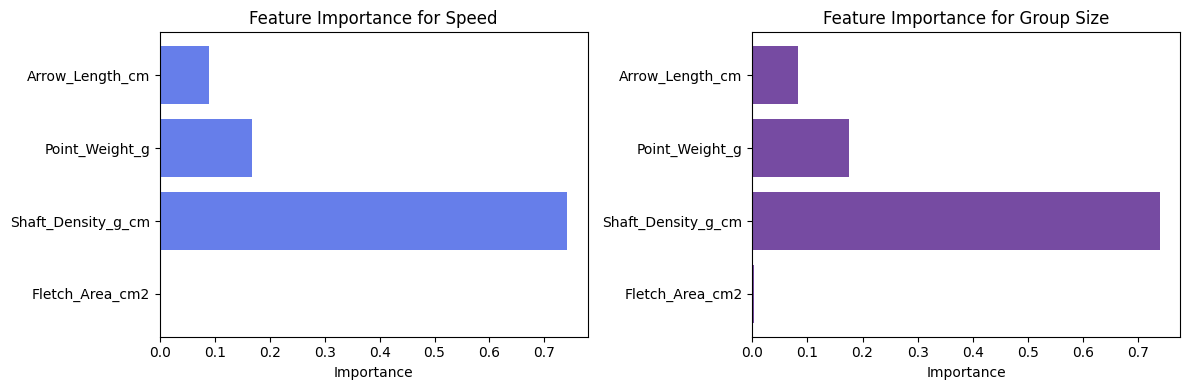

✅ Feature importance plot saved!


In [5]:
import matplotlib.pyplot as plt

# Get feature importance from both estimators
feature_names = X.columns
importances_speed = model.estimators_[0].feature_importances_
importances_accuracy = model.estimators_[1].feature_importances_

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(feature_names, importances_speed, color='#667eea')
axes[0].set_xlabel('Importance')
axes[0].set_title('Feature Importance for Speed')
axes[0].invert_yaxis()

axes[1].barh(feature_names, importances_accuracy, color='#764ba2')
axes[1].set_xlabel('Importance')
axes[1].set_title('Feature Importance for Group Size')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Feature importance plot saved!")

Multi-Objective Bayesian Optimization (Optuna)

In [6]:
# Define the objective function
def objective(trial):
    # Suggest design parameters within realistic bounds
    length = trial.suggest_float('length', 58, 82)
    point_weight = trial.suggest_float('point_weight', 5, 10)
    shaft_density = trial.suggest_float('shaft_density', 0.1, 0.25)
    fletch_area = trial.suggest_float('fletch_area', 3, 15)

    # Create a sample and normalize it
    sample = np.array([[length, point_weight, shaft_density, fletch_area]])
    sample_scaled = scaler.transform(sample)

    # Predict using the trained model
    predictions = model.predict(sample_scaled)
    speed = predictions[0][0]
    group_size = predictions[0][1]

    # Return BOTH objectives
    # We want to MAXIMIZE speed and MINIMIZE group size
    return speed, -group_size  # Negative because Optuna maximizes

# Create a study with TWO directions
study = optuna.create_study(
    directions=['maximize', 'maximize'],  # Maximize speed, maximize (-group_size) = minimize group_size
    sampler=TPESampler(seed=42)
)

# Optimize
print("🔍 Running Bayesian Optimization (500 trials)...")
study.optimize(objective, n_trials=500, show_progress_bar=True)

print("\n✅ Optimization complete!")
print(f"📊 Found {len(study.best_trials)} Pareto-optimal solutions")

# Display top 10 solutions
print("\n🏆 TOP 10 SOLUTIONS (Pareto Front):")
print("=" * 80)
for i, trial in enumerate(study.best_trials[:10]):
    print(f"\n#{i+1}")
    print(f"  Length: {trial.params['length']:.1f} cm")
    print(f"  Point Weight: {trial.params['point_weight']:.1f} g")
    print(f"  Shaft Density: {trial.params['shaft_density']:.3f} g/cm")
    print(f"  Fletch Area: {trial.params['fletch_area']:.1f} cm²")
    print(f"  ➜ Speed: {trial.values[0]:.1f} m/s | Group Size: {-trial.values[1]:.1f} mm")

[I 2026-02-11 16:44:05,570] A new study created in memory with name: no-name-1dd18f57-7804-4a0d-8634-3683a46b405e


🔍 Running Bayesian Optimization (500 trials)...


  0%|          | 0/500 [00:00<?, ?it/s]

[I 2026-02-11 16:44:05,621] Trial 0 finished with values: [63.22723388671875, -32.278892517089844] and parameters: {'length': 66.9889628523367, 'point_weight': 9.75357153204958, 'shaft_density': 0.20979909127171076, 'fletch_area': 10.18390181036444}.
[I 2026-02-11 16:44:05,630] Trial 1 finished with values: [85.13706970214844, -14.291051864624023] and parameters: {'length': 61.744447370618474, 'point_weight': 5.779972601681013, 'shaft_density': 0.10871254182522992, 'fletch_area': 13.394113749299223}.
[I 2026-02-11 16:44:05,666] Trial 2 finished with values: [75.37226867675781, -7.962291240692139] and parameters: {'length': 72.426760281837, 'point_weight': 8.540362888980226, 'shaft_density': 0.10308767414437037, 'fletch_area': 14.638918225943932}.
[I 2026-02-11 16:44:05,686] Trial 3 finished with values: [75.89173126220703, -30.023151397705078] and parameters: {'length': 77.97862337921012, 'point_weight': 6.061695553391381, 'shaft_density': 0.1272737450810651, 'fletch_area': 5.200854118

Pareto Front Analysis

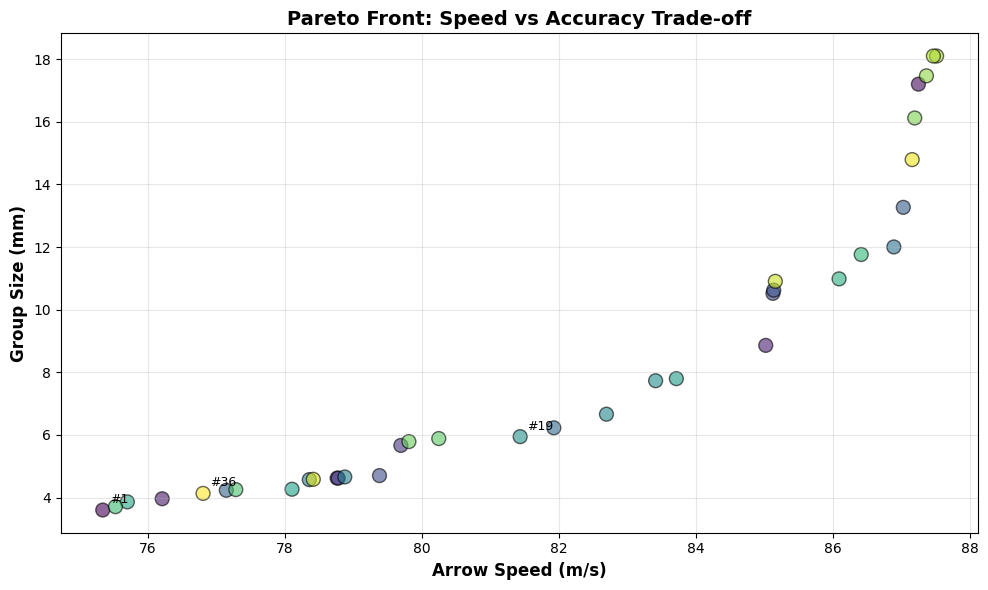

✅ Pareto front visualization saved!


In [7]:
import matplotlib.pyplot as plt

# Extract values from best trials
speeds = [trial.values[0] for trial in study.best_trials]
group_sizes = [-trial.values[1] for trial in study.best_trials]

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(speeds, group_sizes, s=100, alpha=0.6, c=range(len(speeds)), cmap='viridis', edgecolors='black')
plt.xlabel('Arrow Speed (m/s)', fontsize=12, fontweight='bold')
plt.ylabel('Group Size (mm)', fontsize=12, fontweight='bold')
plt.title('Pareto Front: Speed vs Accuracy Trade-off', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Annotate a few points
for i in [0, len(speeds)//2, len(speeds)-1]:
    plt.annotate(f'#{i+1}', (speeds[i], group_sizes[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.savefig('pareto_front.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Pareto front visualization saved!")

Export Best Design

In [8]:
# Select the best trade-off (middle of Pareto front - balanced)
best_idx = len(study.best_trials) // 2
best_trial = study.best_trials[best_idx]

best_design = {
    'Arrow Length (in cm)': best_trial.params['length'],
    'Point Weight (in g)': best_trial.params['point_weight'],
    'Shaft Density (in g/cm\u00b3)': best_trial.params['shaft_density'],
    'Fletch Area (in cm\u00b2)': best_trial.params['fletch_area'],
    'Predicted Speed (in m/s)': best_trial.values[0],
    'Predicted Group Size (in mm)': -best_trial.values[1]
}

# Create DataFrame and save
best_design_df = pd.DataFrame([best_design])
best_design_df.to_csv('optimal_arrow_design.csv', index=False)

print("🏹 RECOMMENDED ARROW DESIGN:")
print("=" * 50)
for key, value in best_design.items():
    print(f"{key}: {value:.2f}")

print("\n✅ Design saved to 'optimal_arrow_design.csv'")

🏹 RECOMMENDED ARROW DESIGN:
Arrow Length (in cm): 59.63
Point Weight (in g): 7.21
Shaft Density (in g/cm³): 0.10
Fletch Area (in cm²): 8.87
Predicted Speed (in m/s): 81.43
Predicted Group Size (in mm): 5.95

✅ Design saved to 'optimal_arrow_design.csv'


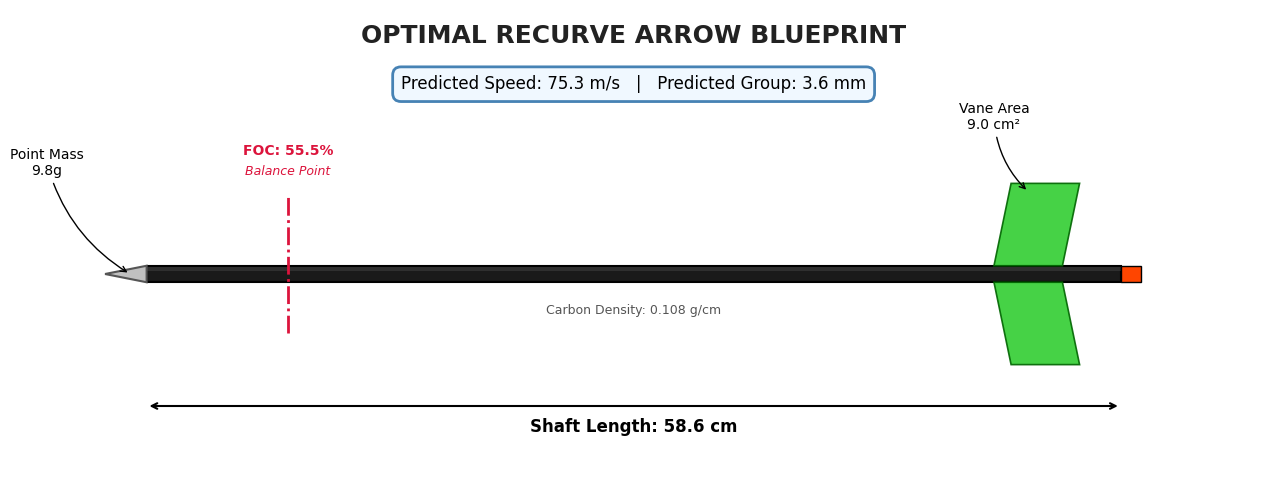

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon, PathPatch
from matplotlib.path import Path
import numpy as np
import pandas as pd

# ==========================================
# PART 1: GET DATA & SAFETY CHECK
# ==========================================

# A. Get the Winning Parameters from the Optimizer
best_trial = study.best_trials[0]
params = best_trial.params

# B. SAFETY CHECK: Re-run these parameters through the ML Model
# This guarantees the numbers on the screen match your model exactly.
input_df = pd.DataFrame([{
    'Arrow_Length_cm': params['length'],
    'Point_Weight_g': params['point_weight'],
    'Shaft_Density_g_cm': params['shaft_density'],
    'Fletch_Area_cm2': params['fletch_area']
}])

# Normalize using the same scaler from training
scaled_input = scaler.transform(input_df)
prediction = model.predict(scaled_input)

# Extract values for plotting
L = params['length']
P = params['point_weight']
D = params['shaft_density']
F = params['fletch_area']
pred_speed = prediction[0][0]     # Fresh Speed Prediction
pred_group = prediction[0][1]     # Fresh Group Prediction

# Physics Calc for Visualization
total_mass = (L * D) + P + 1.5
foc_val = (P / total_mass) * 100
balance_point = (L/2) - ((foc_val-20)/100 * L)

# ==========================================
# PART 2: DRAWING THE BLUEPRINT
# ==========================================

fig, ax = plt.subplots(figsize=(16, 6))
ax.set_facecolor('white')

# --- Carbon Shaft ---
shaft_h = 0.25
shaft = Rectangle((0, -shaft_h/2), L, shaft_h, facecolor='#1a1a1a', edgecolor='black', linewidth=1.5)
ax.add_patch(shaft)
ax.add_patch(Rectangle((0, 0.05), L, 0.05, facecolor='#444444', edgecolor='none', alpha=0.5)) # Shine

# --- Point ---
point_len = 2.5
point = Polygon([[-point_len, 0], [0, shaft_h/2], [0, -shaft_h/2]], closed=True,
                facecolor='#C0C0C0', edgecolor='#555555', linewidth=1.5)
ax.add_patch(point)

# --- Nock ---
nock = Rectangle((L, -shaft_h/2), 1.2, shaft_h, facecolor='#FF4500', edgecolor='black')
ax.add_patch(nock)

# --- Swept Vanes ---
def draw_swept_vane(x_start, y_start, length, height, flip=False):
    y_dir = 1 if not flip else -1
    sweep = length * 0.25
    verts = [
        (x_start, y_start),
        (x_start + length, y_start),
        (x_start + length + sweep, y_start + (height * y_dir)),
        (x_start + sweep, y_start + (height * y_dir)),
        (x_start, y_start)
    ]
    return Polygon(verts, closed=True, facecolor='#32CD32', edgecolor='#006400', alpha=0.9, linewidth=1.2)

vane_len = 3.0 + (F / 8.0)
vane_height = 0.8 + (F / 20.0)
fletch_x = L - 3.5 - vane_len

ax.add_patch(draw_swept_vane(fletch_x, shaft_h/2, vane_len, vane_height, flip=False))
ax.add_patch(draw_swept_vane(fletch_x, -shaft_h/2, vane_len, vane_height, flip=True))

# --- Annotations ---
ax.axvline(x=balance_point, color='#DC143C', linestyle='-.', linewidth=2, ymax=0.6, ymin=0.3)
ax.text(balance_point, 1.8, f"FOC: {foc_val:.1f}%", color='#DC143C', ha='center', fontweight='bold')
ax.text(balance_point, 1.5, "Balance Point", color='#DC143C', ha='center', fontsize=9, style='italic')

ax.annotate('', xy=(0, -2.0), xytext=(L, -2.0), arrowprops=dict(arrowstyle='<->', color='black', linewidth=1.5))
ax.text(L/2, -2.4, f"Shaft Length: {L:.1f} cm", ha='center', fontsize=12, fontweight='bold')

ax.annotate(f'Point Mass\n{P:.1f}g', xy=(-1, 0), xytext=(-6, 1.5), arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2"), ha='center')
ax.annotate(f'Vane Area\n{F:.1f} cm²', xy=(fletch_x + vane_len/2, vane_height), xytext=(fletch_x, 2.2), arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2"), ha='center')
ax.text(L/2, -0.6, f"Carbon Density: {D:.3f} g/cm", ha='center', fontsize=9, color='#555555')

plt.text(L/2, 3.5, "OPTIMAL RECURVE ARROW BLUEPRINT", ha='center', fontsize=18, fontweight='bold', color='#222222')
stats_text = f"Predicted Speed: {pred_speed:.1f} m/s   |   Predicted Group: {pred_group:.1f} mm"
ax.text(L/2, 2.8, stats_text, ha='center', fontsize=12, bbox=dict(boxstyle="round,pad=0.5", facecolor='#F0F8FF', edgecolor='#4682B4', linewidth=2))

ax.set_xlim(-8, L+8)
ax.set_ylim(-3, 4)
ax.axis('off')
plt.show()


In [10]:
import joblib

# 1. Save the Trained Model and the Scaler
joblib.dump(model, 'archery_model.pkl')
joblib.dump(scaler, 'archery_scaler.pkl')

# 2. Download them to your computer
from google.colab import files
files.download('archery_model.pkl')
files.download('archery_scaler.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>